In [13]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import numpy as np
import random
from PIL import Image, ImageOps


In [3]:
imgs = os.listdir('imgs')

In [5]:
i = os.path.join('imgs',random.choices(imgs)[0])
print(i)

imgs/IMG_2562.JPG


In [39]:
img_gray = cv2.imread(i,0)
img = cv2.imread(i)
img_rgb = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

In [27]:

def chromatic_shift_pil(image_path, shift=5):
    # Open image and ensure it has an alpha channel
    base = Image.open(image_path).convert("RGBA")

    # Create magenta and cyan shifted layers
    magenta = Image.new("RGBA", base.size, (255, 0, 255, 0))
    cyan = Image.new("RGBA", base.size, (0, 255, 255, 0))

    # Extract alpha channel as a mask
    alpha = base.split()[3]

    # Paste the alpha channel into the colored layers to give them shape
    magenta.paste((255, 0, 255, 128), mask=alpha)
    cyan.paste((0, 255, 255, 128), mask=alpha)

    # Create a new blank image to combine all layers
    combined = Image.new("RGBA", base.size, (0, 0, 0, 0))

    # Paste the color shadows with offset
    combined.paste(cyan, (-shift, -shift), cyan)
    combined.paste(magenta, (shift, shift), magenta)

    # Paste the base image in the center
    combined.paste(base, (0, 0), base)

    # Save the final image
    #combined.save(output_path, "PNG")
    return combined
# Example usage

In [45]:

def chromatic_shift_cv(image_path, shift=5):
    # Load image with alpha channel if available
    image = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)

    # Separate color channels
    if image.shape[2] == 4:
        b, g, r, a = cv2.split(image)
        base_rgb = cv2.merge((b, g, r))
        alpha = a
    else:
        b, g, r = cv2.split(image)
        base_rgb = image
        alpha = None

    # Create cyan layer (G+B) and magenta layer (R+B)
    cyan = cv2.merge((b, g, np.zeros_like(r)))      # no red
    magenta = cv2.merge((b, np.zeros_like(g), r))   # no green

    # Shift cyan left-up
    M1 = np.float32([[1, 0, -shift], [0, 1, -shift]])
    cyan_shifted = cv2.warpAffine(cyan, M1, (image.shape[1], image.shape[0]))

    # Shift magenta right-down
    M2 = np.float32([[1, 0, shift], [0, 1, shift]])
    magenta_shifted = cv2.warpAffine(magenta, M2, (image.shape[1], image.shape[0]))

    # Blend layers with transparency
    combined = cv2.addWeighted(cyan_shifted, 0.5, magenta_shifted, 0.5, 0)
    final = cv2.addWeighted(combined, 0.7, base_rgb, 1.0, 0)

    # Add alpha back if available
    if alpha is not None:
        result = cv2.merge((final, alpha))
    else:
        result = final

    # Save result
    
    #cv2.imwrite(output_path, result)
    result = cv2.rotate(result, cv2.ROTATE_90_CLOCKWISE)

    return result
# Example usage


In [47]:
chr_cv = chromatic_shift_cv(i)

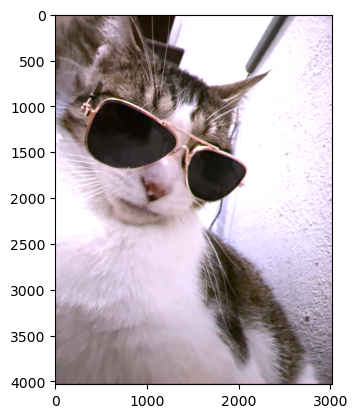

In [49]:
cimg_rgb = cv2.cvtColor(chr_cv,cv2.COLOR_BGR2RGB)
plt.imshow(cimg_rgb)

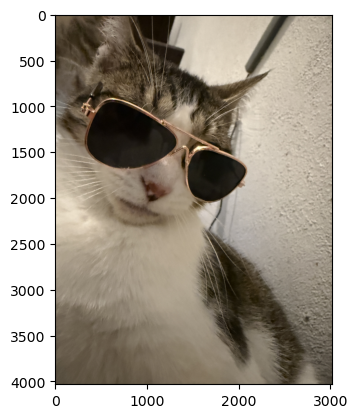

In [43]:
plt.imshow(img_rgb)

In [55]:
chr_cv = chromatic_shift_cv(i,10)

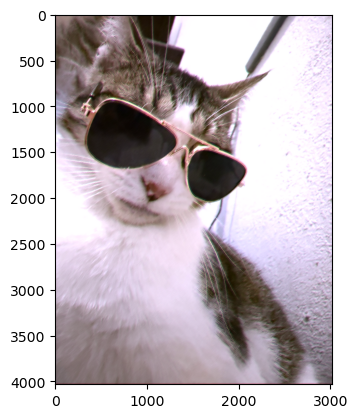

In [57]:
cimg_rgb = cv2.cvtColor(chr_cv,cv2.COLOR_BGR2RGB)
plt.imshow(cimg_rgb)

In [59]:

def shift_BR(image_path, shift_ratio=0.1):
    # Load the image (assume it's BGR)
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError("Image could not be loaded. Check the path.")

    height, width = img.shape[:2]
    shift_px = int(width * shift_ratio)

    # Split the channels
    b, g, r = cv2.split(img)

    # Define shifting matrices
    M_left = np.float32([[1, 0, -shift_px], [0, 1, 0]])
    M_right = np.float32([[1, 0, shift_px], [0, 1, 0]])

    # Shift blue to the left
    b_shifted = cv2.warpAffine(b, M_left, (width, height))

    # Shift red to the right
    r_shifted = cv2.warpAffine(r, M_right, (width, height))

    # Combine channels back (G is unchanged)
    result = cv2.merge((b_shifted, g, r_shifted))

    return result


In [69]:
scv = shift_BR(i,.05)

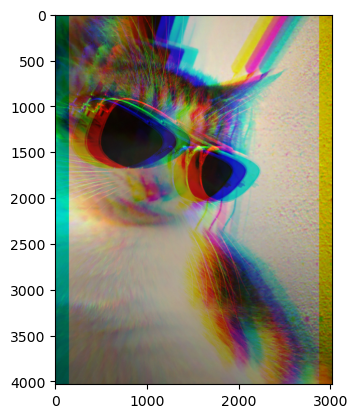

In [71]:
scv_rgb = cv2.cvtColor(scv,cv2.COLOR_BGR2RGB)
plt.imshow(scv_rgb)

In [79]:
scv = shift_BR(i,.03)

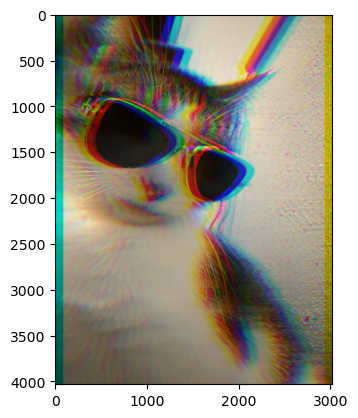

In [81]:
scv_rgb = cv2.cvtColor(scv,cv2.COLOR_BGR2RGB)
plt.imshow(scv_rgb)